# 02 Model Design and Training

This notebook covers the neural network architecture design and the training process for the MNIST dataset classification.

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os


## 2. Load Preprocessed Data
We load the `mnist_preprocessed.npz` file created in the preprocessing step.

In [2]:
data = np.load('../data/mnist_preprocessed.npz')

x_train = data['x_train']
x_test = data['x_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"Loaded train shape: {x_train.shape}")
print(f"Loaded test shape: {x_test.shape}")

Loaded train shape: (60000, 28, 28, 1)
Loaded test shape: (10000, 28, 28, 1)


## 3. Design Neural Network Architecture
A Simple CNN architecture for digit classification focus on high accuracy and low complexity.

In [3]:
model = models.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularization
    layers.Dense(10, activation='softmax') # Output for 10 classes
])

model.summary()

c:\Users\My Device\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the Model
We use Adam optimizer and Categorical Cross-entropy since we've one-hot encoded the labels.

In [4]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## 5. Train the Model
We will train for 10 epochs with a validation split of 10% from the training data.

In [5]:
epochs = 10
history = model.fit(x_train, y_train, epochs=epochs, 
                    batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.9152 - loss: 0.2776 - val_accuracy: 0.9812 - val_loss: 0.0640
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9714 - loss: 0.0942 - val_accuracy: 0.9882 - val_loss: 0.0418
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9796 - loss: 0.0708 - val_accuracy: 0.9887 - val_loss: 0.0390
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9836 - loss: 0.0563 - val_accuracy: 0.9902 - val_loss: 0.0342
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9857 - loss: 0.0487 - val_accuracy: 0.9903 - val_loss: 0.0312
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9871 - loss: 0.0411 - val_accuracy: 0.9907 - val_loss: 0.0328
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9890 - loss: 0.0359 - val_accuracy: 0.9915 - val_loss: 0.0322
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9906 - loss: 0.0314 - 

## 6. Plot Accuracy and Loss curves

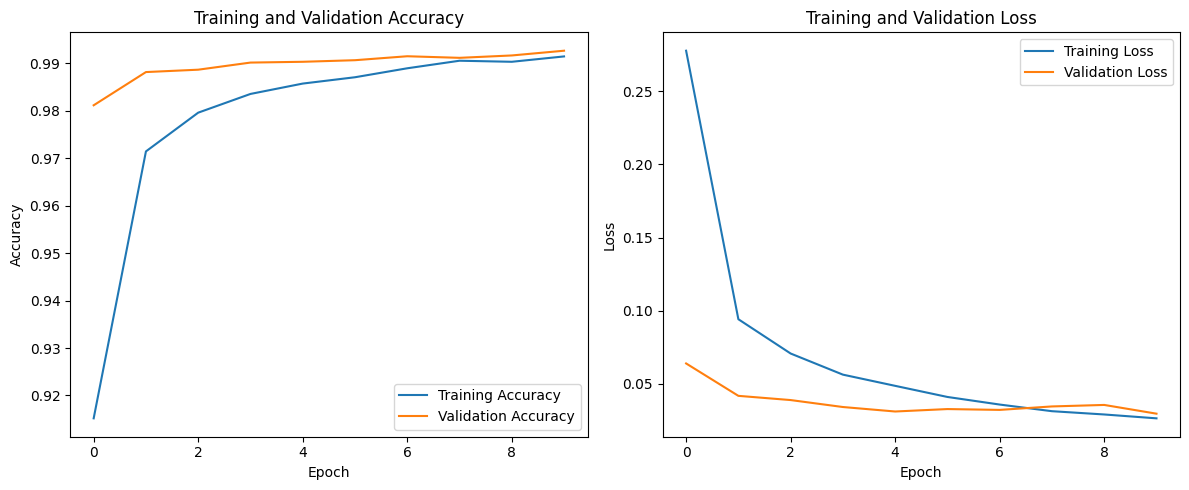

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 7. Save the Model

In [7]:
if not os.path.exists('../models'):
    os.makedirs('../models')
    
model.save('../models/mnist_cnn_v1.h5')
print("Model saved to models/mnist_cnn_v1.h5")

Model saved to models/mnist_cnn_v1.h5
